In [3]:
import pandas as pd
df = pd.read_csv('fraudTest.csv')
print(df.head())
print(df.shape)


   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2020-06-21 12:14:25  2291163933867244   
1           1   2020-06-21 12:14:33  3573030041201292   
2           2   2020-06-21 12:14:53  3598215285024754   
3           3   2020-06-21 12:15:15  3591919803438423   
4           4   2020-06-21 12:15:17  3526826139003047   

                               merchant        category    amt   first  \
0                 fraud_Kirlin and Sons   personal_care   2.86    Jeff   
1                  fraud_Sporer-Keebler   personal_care  29.84  Joanne   
2  fraud_Swaniawski, Nitzsche and Welch  health_fitness  41.28  Ashley   
3                     fraud_Haley Group        misc_pos  60.05   Brian   
4                 fraud_Johnston-Casper          travel   3.19  Nathan   

       last gender                       street  ...      lat      long  \
0   Elliott      M            351 Darlene Green  ...  33.9659  -80.9355   
1  Williams      F             3638 Marsh Union  ...  40.3207 

In [2]:
import os
print(os.getcwd())
print(os.listdir())


c:\Users\Adwaith Nambiar\OneDrive\Desktop\fraud detection
['fraud detection.ipynb', 'fraudTest.csv']


In [4]:
print(df.columns.tolist())


['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [5]:
print(df['is_fraud'].value_counts())
print(df['is_fraud'].value_counts(normalize=True) * 100)


is_fraud
0    553574
1      2145
Name: count, dtype: int64
is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64


In [6]:
print(df.isnull().sum())


Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [7]:
print(df['category'].value_counts())


category
gas_transport     56370
grocery_pos       52553
home              52345
shopping_pos      49791
kids_pets         48692
shopping_net      41779
entertainment     40104
personal_care     39327
food_dining       39268
health_fitness    36674
misc_pos          34574
misc_net          27367
grocery_net       19426
travel            17449
Name: count, dtype: int64


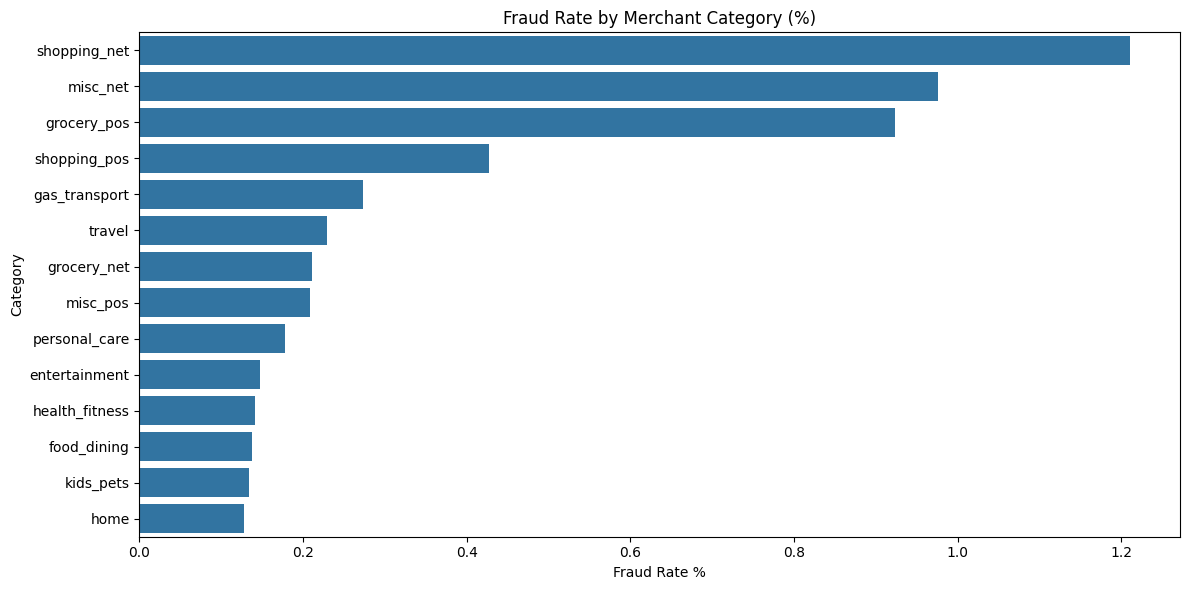

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fraud_by_category = df.groupby('category')['is_fraud'].mean() * 100
fraud_by_category = fraud_by_category.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=fraud_by_category.values, y=fraud_by_category.index)
plt.title('Fraud Rate by Merchant Category (%)')
plt.xlabel('Fraud Rate %')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

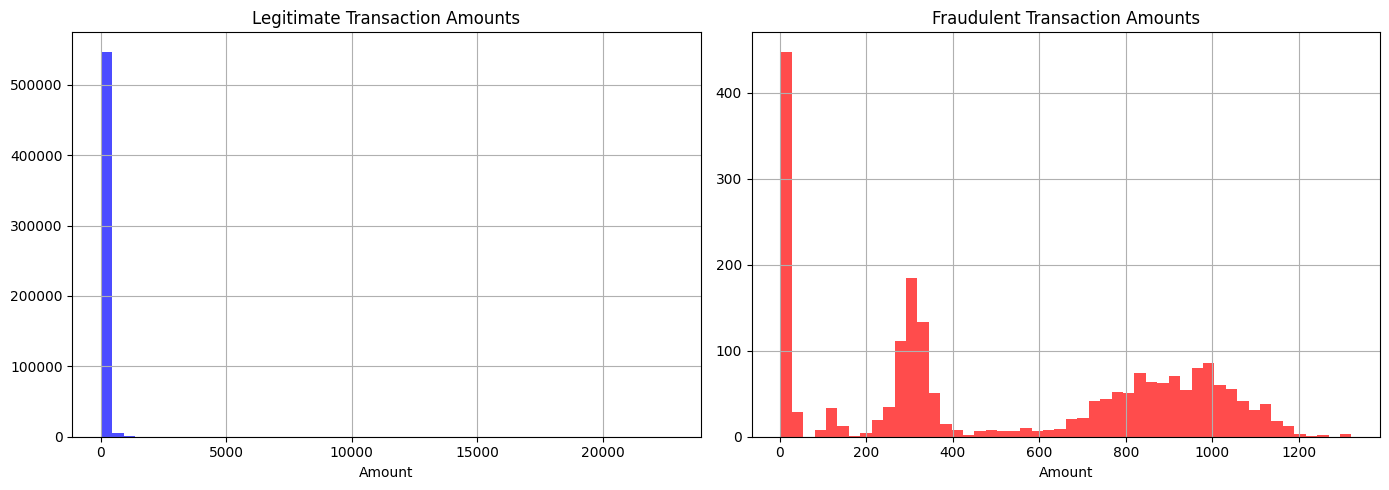

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

df[df['is_fraud']==0]['amt'].hist(bins=50, ax=ax1, color='blue', alpha=0.7)
ax1.set_title('Legitimate Transaction Amounts')
ax1.set_xlabel('Amount')

df[df['is_fraud']==1]['amt'].hist(bins=50, ax=ax2, color='red', alpha=0.7)
ax2.set_title('Fraudulent Transaction Amounts')
ax2.set_xlabel('Amount')

plt.tight_layout()
plt.show()


## Key Finding 4 — Transaction Amounts
Legitimate transactions cluster at low amounts.
Fraudulent transactions show wider distribution with multiple peaks
at small amounts and higher amounts (£300, £800-1000).
Fraudsters deliberately vary transaction amounts to avoid detection.
Transaction amount alone is insufficient to detect fraud.

In [10]:
print(df.groupby('gender')['is_fraud'].mean() * 100)

gender
F    0.381782
M    0.391097
Name: is_fraud, dtype: float64


## Key Finding 5 — Fraud by Gender
Male and female customers show virtually identical fraud rates
(0.38% vs 0.39%). Gender is not a meaningful predictor of fraud
and will likely be excluded from the model.

In [11]:
print(df.groupby('is_fraud')['amt'].describe())

             count        mean         std   min     25%     50%     75%  \
is_fraud                                                                   
0         553574.0   67.614408  152.471931  1.00    9.60   47.15   82.62   
1           2145.0  528.356494  392.747594  1.78  214.51  371.94  907.77   

               max  
is_fraud            
0         22768.11  
1          1320.92  


## Key Finding 6 — Amount vs Fraud
Fraudulent transactions average $528 vs $67 for legitimate.
Median fraudulent transaction ($372) is 7.8x higher than 
legitimate ($47). Transaction amount is a strong fraud predictor.
Interestingly fraudulent max ($1,320) is lower than legitimate max
($22,768) — suggesting fraudsters avoid extremely large amounts.

## Key Finding 3 — Fraud by Category
Online transaction categories (shopping_net, misc_net, grocery_net) 
show significantly higher fraud rates than in-person categories.
shopping_net has highest fraud rate at 1.2%.
This suggests transaction channel is a key fraud risk indicator.

## Key Finding 2 — Data Quality
No missing values across all 23 columns.
No data cleaning required — can proceed directly to analysis.

## Key Finding 1 — Class Imbalance
Dataset contains 555,719 transactions with only 0.38% fraud cases.
Severe class imbalance requires specialized handling — standard accuracy
is misleading here. Will use precision/recall and SMOTE to handle this.
